## **Hepatitis C Virus (HCV) for Egyptian patients**

Group members :
Rachel SHERPA, Estelle SOBESKY, Koralie THERESINE, Yasmine ZEROUAL

**STEP 1 - Import libraries and load the dataset**

In [76]:
!pip install ucimlrepo

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# evaluation
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, f1_score,
roc_auc_score, roc_curve)

# imbalanced data
from collections import Counter
#from imblearn.over_sampling import SMOTE, RandomOverSampler
#from imblearn.under_sampling import RandomUnderSampler

from sklearn.decomposition import PCA


# Informations on the dataset

The dataset used in this project is the Hepatitis C Virus (HCV) for Egyptian patients dataset, obtained from the UCI Machine Learning Repository.

It contains clinical, demographic and laboratory information from 1385 Egyptian patients infected with the Hepatitis C Virus (HCV).
Each record included variables such as age, BMI, blood test results, RNA measurements collected at different treatment stages.

The target variable, called Baseline Histological Staging, represents the stage of liver fibrosis (F0-F3), which indicates the progression of liver damage in HCV patients.
The goal of this dataset is to enable the prediction of the fibrosis stage based on these medical features.

This topic was chosen because Hepatitis C remains a major public health issue in many countries, and using machine learning models to predict liver fibrosis can help improve early diagnosis and patient management. It has a real impact on the world.

**STEP 2 - Load the dataset**

In [13]:
# ML tools
from ucimlrepo import fetch_ucirepo

# Fetch dataset (UCI id = 503)
hcv = fetch_ucirepo(id=503)

# Extract features and target
X = hcv.data.features
y = hcv.data.targets

# Merge for easier exploration
df = pd.concat([X, y], axis=1)

# Quick overview
print("Shape of dataset:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape of dataset: (1385, 29)
Columns: ['Age ', 'Gender', 'BMI', 'Fever', 'Nausea/Vomting', 'Headache ', 'Diarrhea ', 'Fatigue & generalized bone ache ', 'Jaundice ', 'Epigastric pain ', 'WBC', 'RBC', 'HGB', 'Plat', 'AST 1', 'ALT 1', 'ALT4', 'ALT 12', 'ALT 24', 'ALT 36', 'ALT 48', 'ALT after 24 w', 'RNA Base', 'RNA 4', 'RNA 12', 'RNA EOT', 'RNA EF', 'Baseline histological Grading', 'Baselinehistological staging']


,Age,Gender,BMI,Fever,Nausea/Vomting,Headache,Diarrhea,Fatigue & generalized bone ache,Jaundice,Epigastric pain,...,ALT 36,ALT 48,ALT after 24 w,RNA Base,RNA 4,RNA 12,RNA EOT,RNA EF,Baseline histological Grading,Baselinehistological staging
0,56,1,35,2,1,1,1,2,2,2,...,5,5,5,655330,634536,288194,5,5,13,2
1,46,1,29,1,2,2,1,2,2,1,...,57,123,44,40620,538635,637056,336804,31085,4,2
2,57,1,33,2,2,2,2,1,1,1,...,5,5,5,571148,661346,5,735945,558829,4,4
3,49,2,33,1,2,1,2,1,2,1,...,48,77,33,1041941,449939,585688,744463,582301,10,3
4,59,1,32,1,1,2,1,2,2,2,...,94,90,30,660410,738756,3731527,338946,242861,11,1


**STEP 3 — Descriptive analysis of your data (EDA)**

In [17]:
# Basic info about the dataset
print("General information")
df.info()

# Descriptive statistics
print("\n Statistical summary")
display(df.describe())

# Check for missing values
print("\n Missing values per column")
missing_values = df.isna().sum()
display(missing_values[missing_values > 0])
print(df.isnull().sum())

# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")



General information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1385 entries, 0 to 1384
Data columns (total 29 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               1385 non-null   int64  
 1   Gender                            1385 non-null   int64  
 2   BMI                               1385 non-null   int64  
 3   Fever                             1385 non-null   int64  
 4   Nausea/Vomting                    1385 non-null   int64  
 5   Headache                          1385 non-null   int64  
 6   Diarrhea                          1385 non-null   int64  
 7   Fatigue & generalized bone ache   1385 non-null   int64  
 8   Jaundice                          1385 non-null   int64  
 9   Epigastric pain                   1385 non-null   int64  
 10  WBC                               1385 non-null   int64  
 11  RBC                               1385 non-null  

,Age,Gender,BMI,Fever,Nausea/Vomting,Headache,Diarrhea,Fatigue & generalized bone ache,Jaundice,Epigastric pain,...,ALT 36,ALT 48,ALT after 24 w,RNA Base,RNA 4,RNA 12,RNA EOT,RNA EF,Baseline histological Grading,Baselinehistological staging
count,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,...,1385.000000,1385.000000,1385.000000,1.385000e+03,1.385000e+03,1.385000e+03,1385.000000,1385.000000,1385.000000,1385.000000
mean,46.319134,1.489531,28.608664,1.515523,1.502527,1.496029,1.502527,1.498917,1.501083,1.503971,...,83.117690,83.629603,33.438267,5.909512e+05,6.008956e+05,2.887536e+05,287660.336462,291378.290975,9.761733,2.536462
std,8.781506,0.500071,4.076215,0.499939,0.500174,0.500165,0.500174,0.500179,0.500179,0.500165,...,26.399031,26.223955,7.073569,3.539354e+05,3.623151e+05,2.853507e+05,264559.525070,267700.691713,4.023896,1.121392
min,32.000000,1.000000,22.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,5.000000,5.000000,5.000000,1.100000e+01,5.000000e+00,5.000000e+00,5.000000,5.000000,3.000000,1.000000
25%,39.000000,1.000000,25.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,61.000000,61.000000,28.000000,2.692530e+05,2.708930e+05,5.000000e+00,5.000000,5.000000,6.000000,2.000000
50%,46.000000,1.000000,29.000000,2.000000,2.000000,1.000000,2.000000,1.000000,2.000000,2.000000,...,84.000000,83.000000,34.000000,5.931030e+05,5.978690e+05,2.343590e+05,251376.000000,244049.000000,10.000000,3.000000
75%,54.000000,2.000000,32.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,106.000000,106.000000,40.000000,8.867910e+05,9.090930e+05,5.248190e+05,517806.000000,527864.000000,13.000000,4.000000
max,61.000000,2.000000,35.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,128.000000,128.000000,45.000000,1.201086e+06,1.201715e+06,3.731527e+06,808450.000000,810333.000000,16.000000,4.000000



 Missing values per column


Series([], dtype: int64)

Age                                 0
Gender                              0
BMI                                 0
Fever                               0
Nausea/Vomting                      0
Headache                            0
Diarrhea                            0
Fatigue & generalized bone ache     0
Jaundice                            0
Epigastric pain                     0
WBC                                 0
RBC                                 0
HGB                                 0
Plat                                0
AST 1                               0
ALT 1                               0
ALT4                                0
ALT 12                              0
ALT 24                              0
ALT 36                              0
ALT 48                              0
ALT after 24 w                      0
RNA Base                            0
RNA 4                               0
RNA 12                              0
RNA EOT                             0
RNA EF      

There are no categorical columns in this dataset. All variables are numerical (continuous or discrete clinical measurements).
Therefore, we will only apply numerical preprocessing (scaling and imputation) in the next steps no encoding is required.

***Visualization***

Target column: Baselinehistological staging


C:\Users\ZEROUAL\AppData\Local\Temp\ipykernel_156408\3055647478.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y[target_col], palette='Set2')


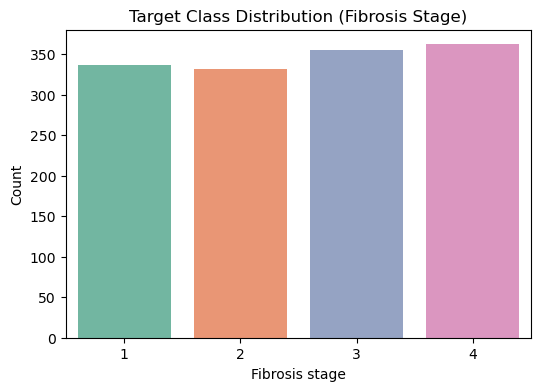


Class counts:
Baselinehistological staging
1    336
2    332
3    355
4    362
Name: count, dtype: int64

Class proportions (%):
Baselinehistological staging
1    24.26
2    23.97
3    25.63
4    26.14
Name: count, dtype: float64
Ratio (majority/minority):  1.09

Interpretation:
Low imbalance. No resampling needed


In [25]:
#  Target variable distribution

target_col = y.columns[0] if isinstance(y, pd.DataFrame) else 'target'
print("Target column:", target_col)

plt.figure(figsize=(6,4))
sns.countplot(x=y[target_col], palette='Set2')
plt.title("Target Class Distribution (Fibrosis Stage)")
plt.xlabel("Fibrosis stage")
plt.ylabel("Count")
plt.show()

# Display exact class counts
print("\nClass counts:")
class_counts= y[target_col].value_counts().sort_index()
print(class_counts)

total=class_counts.sum()
proportions=(class_counts/total *100).round(2)
print("\nClass proportions (%):")
print(proportions)

# compute ratios
max_count =class_counts.max()
min_count=class_counts.min()
ratio= round(max_count/min_count,3)
print("Ratio (majority/minority): ",ratio)

# Interpretation
print("\nInterpretation:")
if ratio <= 5:
    print("Low imbalance. No resampling needed")
elif ratio <= 20:
    print("moderate imbalance. Resampling can be considered")
elif ratio > 50:
    print("high imbalance. Resampling strongly recommended")
else:
    print("Intermediate imbalance (between 1:20 and 1:50)")

The proportions range between 23.97% and 26.14%, indicating that allc lasses contain a similar number of observations.
Since the ratio (1.09) remains within the low imbalance interval and the class frequencies are almost identical, we conclude that the dataet is balanced and no resampling (SMOTE, oversampling, undersampling) are required.

In [ ]:
# print(df['Baselinehistological staging'].value_counts())same thing

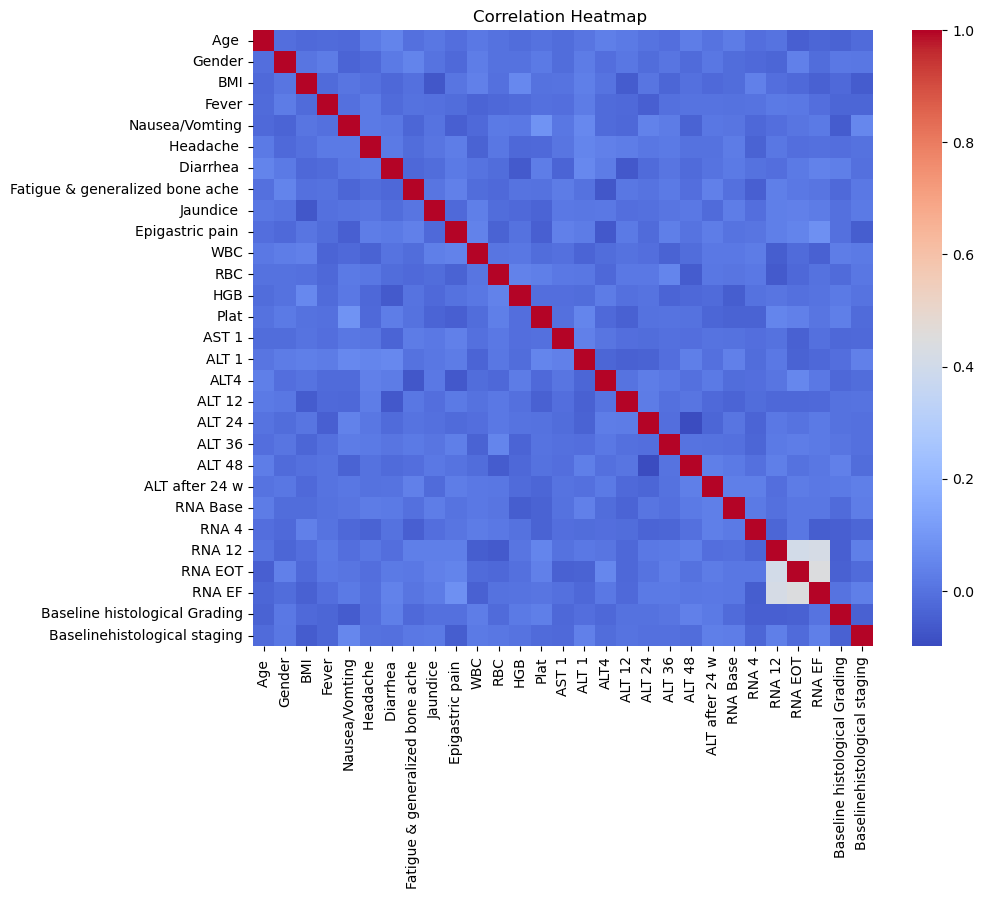

In [28]:
# Correlation heatmap

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap ")
plt.show()
# We only have numerical values so no need to write "numeric_only=true"


The heatmap shows that most features are only weakly correlated. The target variable shows no strong linear correlation with any feature, so non-linear models will perform better.

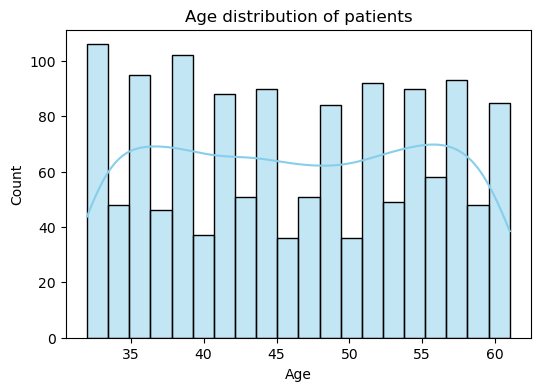

In [31]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age '], bins=20, kde=True, color='skyblue')
plt.title('Age distribution of patients')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


The histogram shows the distribution of patients'ages in the dataset.
Most patients are between 30 and 60 years old, with no extreme outliers. 
The number of patients is quite balanced across different age ranges, although there are more indivuals around 30-40 years old.
This suggests that the dataset represents adult and middle-aged Egyptian patients.

C:\Users\ZEROUAL\AppData\Local\Temp\ipykernel_156408\947071455.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Baselinehistological staging', y='ALT 24', data=df, palette='Set3')


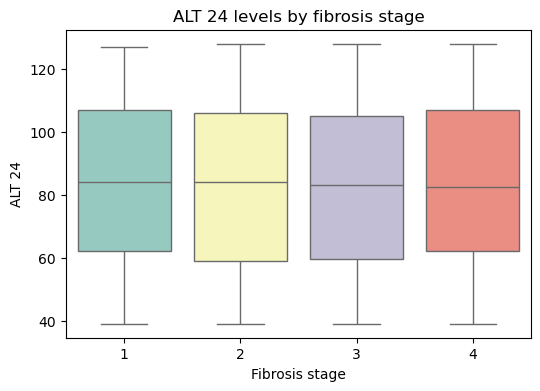

In [33]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Baselinehistological staging', y='ALT 24', data=df, palette='Set3')
plt.title('ALT 24 levels by fibrosis stage')
plt.xlabel('Fibrosis stage')
plt.ylabel('ALT 24')
plt.show()

the variable ALT 24 represents the level of Alanine Aminotransferase (ALT) measured 24 weeks after treatment. ALT is an enzyme found mainly in the liver and its level increases when liver cells are damaged. Therefore, it is a key clinical indicator of liver inflammation and injury in patients with hepatitis C.

ALT 24 levels are similar across all fibrosis stages, with a slight rise in stage 4.

Some outliers appear in the ALT24 values across different fibrosis stages. However, these values are clinically plausible, as liver enzyme levels naturally vary among hepatitis C patients. Since the outliers reflect real medical variability rather than data errors, we decided to keep them in the dataset and not apply any outlier removal.

<Axes: xlabel='ALT 1', ylabel='Count'>

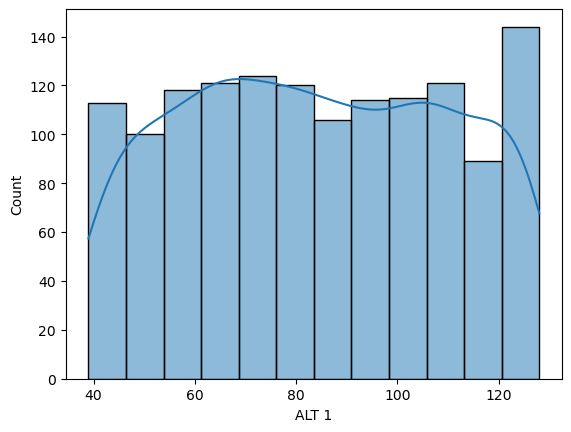

In [35]:
sns.histplot(df["ALT 1"], kde=True)

ALT 1 represents the baseline ALT enzyme level. Its distribution indicated differnt levels of liver inflammation among patients, with no extreme outliers.

In [42]:
#Check for inconsistencies
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("/", "_").str.replace("&", "and").str.replace("__", "_")
print(df.columns.tolist())

['Age', 'Gender', 'BMI', 'Fever', 'Nausea_Vomting', 'Headache', 'Diarrhea', 'Fatigue_and_generalized_bone_ache', 'Jaundice', 'Epigastric_pain', 'WBC', 'RBC', 'HGB', 'Plat', 'AST_1', 'ALT_1', 'ALT4', 'ALT_12', 'ALT_24', 'ALT_36', 'ALT_48', 'ALT_after_24_w', 'RNA_Base', 'RNA_4', 'RNA_12', 'RNA_EOT', 'RNA_EF', 'Baseline_histological_Grading', 'Baselinehistological_staging']


**STEP 4 — Data Pre-processing**

*Detect column types*

In [45]:
# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: []
Numeric columns: ['Age', 'Gender', 'BMI', 'Fever', 'Nausea_Vomting', 'Headache', 'Diarrhea', 'Fatigue_and_generalized_bone_ache', 'Jaundice', 'Epigastric_pain', 'WBC', 'RBC', 'HGB', 'Plat', 'AST_1', 'ALT_1', 'ALT4', 'ALT_12', 'ALT_24', 'ALT_36', 'ALT_48', 'ALT_after_24_w', 'RNA_Base', 'RNA_4', 'RNA_12', 'RNA_EOT', 'RNA_EF', 'Baseline_histological_Grading', 'Baselinehistological_staging']


The dataset is a tabular numeric dataset, as all features are numerical measurements (like laboratory values, clinical indicators...). 
No categorical variables are present. Therefore, the preprocessing pipeline only includes numerical imputation and scaling.

Although the dataset is numeric tabular data, it does not require SMOTE or oversampling because the class distribution is well balanced (ratio = 1.09). Therefore, standard preprocessing and model training can be applied without any resampling technique.

*Handle missing values (if any)*

This preprocessing pipeline is designed to handle missing values and scale numeric features.
The SimpleImputer (with median strategy) would replace missing numeric values with the column median.
However, in this dataset there are no missing values, so the imputer will not modify the data.
We still include it for good practice and reproducibility in case new data contain NaNs.

In [47]:
# Numeric data preprocessing: imputation + scaling
numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])

# Because we have no categorical variables, we keep only the numeric transformer
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_cols)])

*Train/Test split*

In [49]:
# Extract X (features) and y (target)
X = df.drop(columns=[df.columns[-1]])  # all columns except target
y = df[df.columns[-1]]                 # last column = target

# Stratified split: 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (1108, 28)
Test set shape: (277, 28)


*Formalization of the Problem*

The objective of this project is to predict the Baseline Histological Staging (fibrosis stage) of Egyptian patients infected with the Hepatitis C Virus (HCV) using their demographic, clinical, and laboratory data.

Each patient in the dataset is described by numerical attributes such as age, body mass index (BMI), and several blood test results (such as ALT, AST, bilirubin, platelets, albumin, etc.).

The goal is to determine the stage of liver fibrosis, a medical indicator of liver damage based on these features.
This is a multiclass classification problem, since the target variable (fibrosis stage) contains several distinct categories (for example, F0, F1, F2, F3).

All predictors in the dataset are numerical, meaning that no categorical encoding is required.
For the evaluation, the primary metric is the Macro F1-score, which gives equal importance to all classes and is well suited to imbalanced datasets.
As secondary metrics, we will use accuracy, weighted F1-score, and a confusion matrix to visualize class-level performance.
Precision–Recall curves and ROC–AUC (one-vs-rest) analyses may also be used to provide additional insights into model behavior.

The goal of this step is to build a clean and reproducible baseline model (using Logistic Regression and/or Decision Tree) in order to evaluate initial predictive performance before moving to more advanced techniques in the next steps.

In [59]:
# redefine numeric columns based on X only (without target)
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
# rebuild the preprocessor
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
preprocessor = ColumnTransformer(
    transformers=[('num', numeric_transformer, numeric_cols)]
)

In [74]:
# logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print("\n Logistic Regression Results ")
print(classification_report(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

# random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n Random Forest Results ")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))



C:\Users\ZEROUAL\ANACONDA\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



 Logistic Regression Results 
              precision    recall  f1-score   support

           1       0.36      0.12      0.18        67
           2       0.29      0.36      0.32        67
           3       0.28      0.28      0.28        71
           4       0.34      0.47      0.39        72

    accuracy                           0.31       277
   macro avg       0.32      0.31      0.29       277
weighted avg       0.32      0.31      0.30       277

Accuracy: 0.3104693140794224

 Random Forest Results 
              precision    recall  f1-score   support

           1       0.17      0.15      0.16        67
           2       0.28      0.25      0.27        67
           3       0.21      0.21      0.21        71
           4       0.28      0.32      0.30        72

    accuracy                           0.23       277
   macro avg       0.23      0.23      0.23       277
weighted avg       0.23      0.23      0.23       277

Accuracy: 0.23465703971119134


 Both baseline models (Logistic Regression and Random Forest) show low performance,indicating that the dataset is challenging and potentially imbalanced. These results will serve as reference baselines for later improvements using class balancing techniques and hyperparameter tuning.


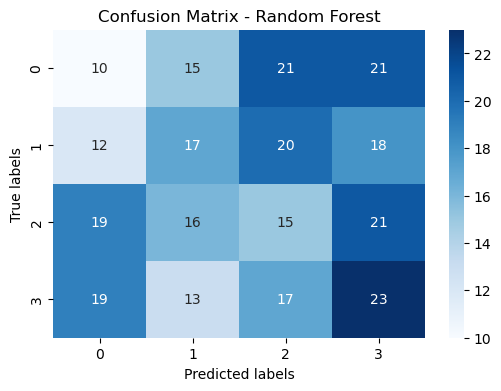

In [89]:
# Confusion Matrix for Random Forest 

# A confusion matrix allows us to visualize how the model misclassifies each class

cm = confusion_matrix(y_test, y_pred_rf)

# Create a heatmap for better visualization
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()


The confusion matrix shows that the Random Forest model struggles to clearly separate the fibrosis stages.  
Many predictions are off the diagonal, meaning that the model frequently confuses neighboring stages (for example, F2 vs F3).  
This indicates that the classes are not linearly separable and that additional tuning or feature engineering may be required.  
However, the matrix also shows that some classes are recognized more consistently than others, which is a good starting point for improvement.


In [71]:
#Baseline models comparison
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, multi_class="multinomial"),
    "SVM (RBF)": SVC(kernel="rbf", probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}
results = {}

for name, model in models.items():
    clf=Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    print(f"\n {name} ")
    print("Accuracy:", acc)
    print("Macro f1-score:", f1)
    print("Classification report:\n", classification_report(y_test, y_pred))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

    results[name] = {"accuracy": acc, "f1_macro": f1}



 Logistic Regression 
Accuracy: 0.24548736462093862
Macro f1-score: 0.24385837941254804
Classification report:
               precision    recall  f1-score   support

           1       0.20      0.18      0.19        67
           2       0.26      0.28      0.27        67
           3       0.26      0.24      0.25        71
           4       0.25      0.28      0.26        72

    accuracy                           0.25       277
   macro avg       0.24      0.24      0.24       277
weighted avg       0.24      0.25      0.24       277

Confusion matrix:
 [[12 20 15 20]
 [16 19 17 15]
 [14 16 17 24]
 [18 17 17 20]]

 SVM (RBF) 
Accuracy: 0.26353790613718414
Macro f1-score: 0.2620424724722709
Classification report:
               precision    recall  f1-score   support

           1       0.25      0.22      0.24        67
           2       0.23      0.24      0.23        67
           3       0.29      0.27      0.28        71
           4       0.28      0.32      0.30        72

The baseline models achieve low accuracy and macro f1-scores. This is expected because the problem involves four classes,and many clinical features are very similar between the fibrosis stages, this makes  them difficult to separate. The models are not yet adapted to the dataset.These results should improve once we apply hyperparameter tuning, PCA, and ensemble models.

In [ ]:
#Hyperparameter tuning